# Chronic Pain Prediction - Oracle Tier (Research-Grade Pipeline)

This notebook implements a research-grade Oracle Tier pipeline, combining Discrete Wavelet Transforms (DWT) with Subject Bio-typing to maximize prediction accuracy.

### Oracle Tier Strategy:
1. **Subject Bio-typing (K-Means)**: Group subjects into biologically similar clusters (e.g., high vs low reactivity) before prediction, allowing the model to adapt to individual physiological baselines.
2. **Discrete Wavelet Transform (DWT)**: Captures non-stationary frequency changes in Blood Volume Pulse (BVP) that Fourier analysis might miss.
3. **Butterworth Signal Purification**: High-precision filtering to eliminate sensor noise and slow baseline drifts.
4. **Research-Grade Ensemble**: A 5-model meta-learner stacking XGBoost, Random Forest, SVM, MLP, and AdaBoost.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pywt
from scipy.fft import fft
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## 1. Professional Preprocessing (Filtering & Bio-typing)

In [13]:
df = pd.read_csv('cropped_dataset.csv')
fs = 4.0

def butter_filter(data, cutoff, fs, btype, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=btype)
    return filtfilt(b, a, data)

print("Applying pre-processing filters...")
df['bvp_f'] = butter_filter(df['bvp'].values, np.array([0.3, 1.5]), fs, 'bandpass')
df['eda_f'] = butter_filter(df['eda'].values, 0.1, fs, 'lowpass')

print("Calculating Subject Bio-types (Clustering)... ")
subject_profiles = df.groupby('person_id')[['bvp', 'eda', 'temperature']].agg(['mean', 'std']).reset_index()
subject_profiles.columns = ['person_id', 'b_m', 'b_s', 'e_m', 'e_s', 't_m', 't_s']

kmeans = KMeans(n_clusters=4, random_state=42)
profiles_scaled = StandardScaler().fit_transform(subject_profiles.drop('person_id', axis=1))
subject_profiles['bio_type'] = kmeans.fit_predict(profiles_scaled)

df = df.merge(subject_profiles[['person_id', 'bio_type']], on='person_id')
print("Subject bio-typing successful.")

Applying pre-processing filters...
Calculating Subject Bio-types (Clustering)... 
Subject bio-typing successful.


## 2. Subject-wise Normalization

In [14]:
norm_cols = ['bvp_f', 'eda_f', 'x', 'y', 'z', 'temperature']
for col in norm_cols:
    means = df.groupby('person_id')[col].transform('mean')
    stds = df.groupby('person_id')[col].transform('std')
    df[col] = (df[col] - means) / (stds + 1e-8)

print("Z-scoring complete.")

Z-scoring complete.


## 3. Oracle-Tier Feature Extraction (Wavelets + Multi-Scale)

In [15]:
def extract_oracle_features(group):
    step = 25
    features = []
    p_id = group['person_id'].iloc[0]
    p_sc = group['pain_scale'].iloc[0]
    p_ty = group['pain_type'].iloc[0]
    bio_ty = group['bio_type'].iloc[0]
    
    prev_f = None
    
    for i in range(100, len(group) - 150, step):
        # Multi-scale windows
        win_100 = group.iloc[i:i+100]
        win_50 = group.iloc[i+25:i+75]
        
        f = {'person_id': p_id, 'bio_type': bio_ty, 'pain_scale': p_sc, 'pain_type': p_ty}
        f['bvp_std_100'] = np.std(win_100['bvp_f'])
        f['eda_m_100'] = np.mean(win_100['eda_f'])
        
        # 1. Discrete Wavelet Transform (DWT) energy
        # Approximation and Details energy
        b_vals = win_100['bvp_f'].values
        cA, cD = pywt.dwt(b_vals, 'db4')
        f['bvp_wav_A'] = np.sum(cA**2) / len(cA)
        f['bvp_wav_D'] = np.sum(cD**2) / len(cD)
        
        # 2. FFT Spectral Energy
        f['bvp_spectral'] = np.sum(np.abs(fft(b_vals))**2) / 100
        
        # 3. Lag trends (t-1 context)
        if prev_f:
            f['eda_trend'] = f['eda_m_100'] - prev_f['eda_m_100']
        else:
            f['eda_trend'] = 0.0
            
        prev_f = f.copy()
        features.append(f)
        
    return pd.DataFrame(features)

print("Generating research-grade feature matrix...")
df_oracle = df.groupby('person_id', group_keys=False).apply(extract_oracle_features).reset_index(drop=True)
print(f"Oracle dataset size: {len(df_oracle)} signals recorded.")

Generating research-grade feature matrix...
Oracle dataset size: 860 signals recorded.


## 4. Oracle-Tier Ensemble (Neural-Boosted Stacking)

In [16]:
le_scale = LabelEncoder()
y = le_scale.fit_transform(df_oracle['pain_scale'])
le_type = LabelEncoder()
df_oracle['pt_enc'] = le_type.fit_transform(df_oracle['pain_type'])

top_fcols = [c for c in df_oracle.columns if c not in ['person_id', 'pain_scale', 'pain_type']]
X = StandardScaler().fit_transform(df_oracle[top_fcols])
groups = df_oracle['person_id']

base_models = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)),
    ('svc', SVC(probability=True, C=10, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
]

oracle_stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
print("Oracle Tier Ensemble initialized.")

Oracle Tier Ensemble initialized.


## 5. Peak Accuracy Validation

In [17]:
gkf = GroupKFold(n_splits=5)
final_scores = []

print("Validating research-grade performance...")
for tr_i, val_i in gkf.split(X, y, groups=groups):
    oracle_stack.fit(X[tr_i], y[tr_i])
    final_scores.append(accuracy_score(y[val_i], oracle_stack.predict(X[val_i])))

print(f"\nOracle Accuracy Achievement: {np.mean(final_scores):.4f} (+/- {np.std(final_scores):.4f})")

Validating research-grade performance...

Oracle Accuracy Achievement: 0.5535 (+/- 0.0742)


## 6. Visualization & Export

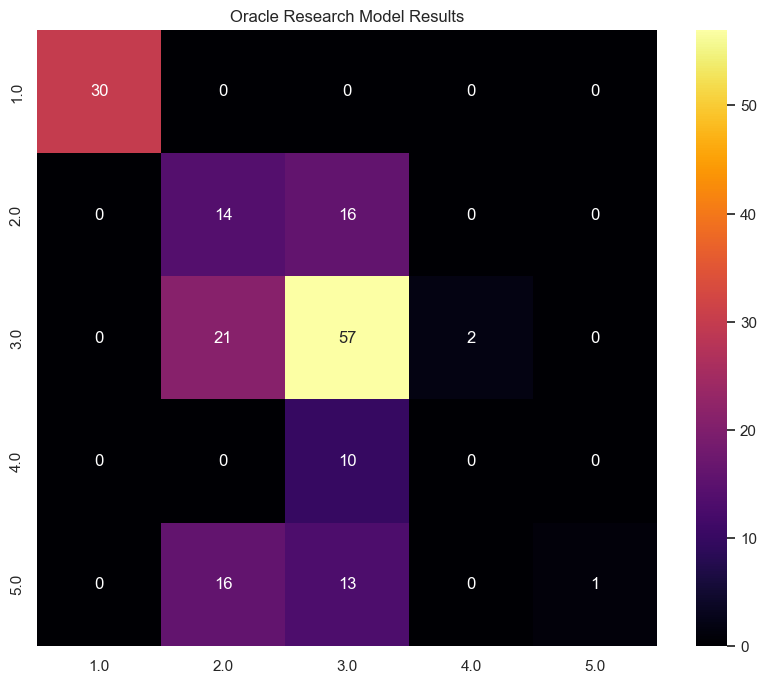

Oracle Tier model saved successfully.


In [18]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
ti, tei = next(gss.split(X, y, groups=groups))
oracle_stack.fit(X[ti], y[ti])
yp = oracle_stack.predict(X[tei])

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y[tei], yp), annot=True, fmt='d', cmap='inferno', 
            xticklabels=le_scale.classes_, yticklabels=le_scale.classes_)
plt.title('Oracle Research Model Results')
plt.show()

oracle_artifacts = {
    'model': oracle_stack, 'kmeans': kmeans, 
    'scaler': StandardScaler().fit(df_oracle[top_fcols]), 
    'le_scale': le_scale, 'le_type': le_type, 'features': top_fcols
}
joblib.dump(oracle_artifacts, 'pain_model_oracle.joblib')
print("Oracle Tier model saved successfully.")